## Step 1 :- Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2 :- Load the Dataset

In [2]:
data = pd.read_csv(r"C:\Users\Ankit_\Downloads\Datasets\goldstock v1.csv")

## Step 3 :- EDA 



In this section, we analyze gold price data statistically and visually to understand patterns and distributions.

This analysis includes:
- Descriptive statistics  
- Missing values  
- Price distribution  
- Price trends over time  

In [3]:
data.head()

,Unnamed: 0,Date,Close,Volume,Open,High,Low
0,0,2024-01-19,2029.3,166078.0,2027.4,2041.9,2022.2
1,1,2024-01-18,2021.6,167013.0,2009.1,2025.6,2007.7
2,2,2024-01-17,2006.5,245194.0,2031.7,2036.1,2004.6
3,3,2024-01-16,2030.2,277995.0,2053.4,2062.8,2027.6
4,4,2024-01-12,2051.6,250946.0,2033.2,2067.3,2033.1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2511 entries, 0 to 2510
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  2511 non-null   int64  
 1   Date        2511 non-null   object 
 2   Close       2511 non-null   float64
 3   Volume      2511 non-null   float64
 4   Open        2511 non-null   float64
 5   High        2511 non-null   float64
 6   Low         2511 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 137.4+ KB


In [5]:
data.shape

(2511, 7)

In [6]:
data.describe()

,Unnamed: 0,Close,Volume,Open,High,Low
count,2511.000000,2511.000000,2511.000000,2511.000000,2511.000000,2511.000000
mean,1260.792911,1498.726085,185970.770609,1498.725528,1508.451454,1488.869932
std,729.262879,298.824811,97600.769382,299.118187,301.262244,296.417703
min,0.000000,1049.600000,1.000000,1051.500000,1062.700000,1045.400000
25%,630.500000,1249.850000,126693.500000,1249.500000,1257.300000,1242.350000
50%,1259.000000,1332.800000,175421.000000,1334.000000,1342.400000,1326.600000
75%,1888.500000,1805.850000,234832.000000,1805.600000,1815.450000,1793.050000
max,2532.000000,2093.100000,787217.000000,2094.400000,2098.200000,2074.600000


In [7]:
data.isnull().sum()

Unnamed: 0    0
Date          0
Close         0
Volume        0
Open          0
High          0
Low           0
dtype: int64

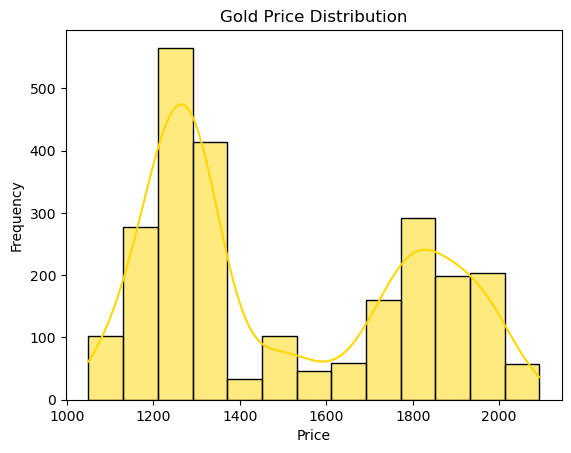

In [8]:
# Price distribution

sns.histplot(data['Close'], kde=True, color='gold')
plt.title('Gold Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


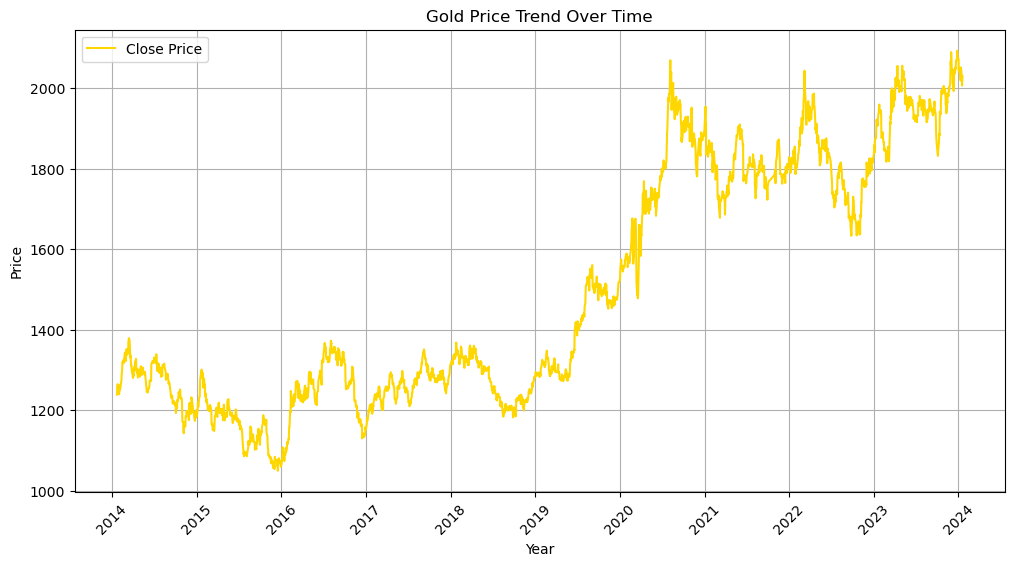

In [9]:
## Price Trends Over Time
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

plt.figure(figsize=(12, 6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='gold')
plt.title("Gold Price Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Price")
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.show()


## Step 4 :- Data Preprocessing

Before building the model, we need to ensure that the data is clean and ready to be used. At this stage, the following steps are performed:

Handling missing values
- Feature selection
- Splitting the data into training and testing sets

In [10]:
data.columns

Index(['Unnamed: 0', 'Date', 'Close', 'Volume', 'Open', 'High', 'Low'], dtype='object')

In [11]:
# # Step 1: Remove missing values --  there is no missing values
# data = data.dropna()
# print("Shape after removing missing values:", data.shape)

In [12]:
# Step 2: Convert Date column
data['Date'] = pd.to_datetime(data['Date'])

In [13]:
data.head()

,Unnamed: 0,Date,Close,Volume,Open,High,Low
2510,2532,2014-01-22,1238.6,80262.0,1240.5,1243.5,1235.5
2509,2531,2014-01-23,1262.5,41697.0,1235.1,1267.1,1230.8
2508,2530,2014-01-24,1264.5,34998.0,1264.3,1273.2,1256.9
2507,2529,2014-01-27,1263.5,63419.0,1269.9,1280.1,1252.0
2506,2528,2014-01-28,1250.5,81426.0,1254.9,1261.9,1248.0


In [14]:
# Step 3: Sort data by Date
data = data.sort_values(by='Date')

In [15]:
# Step 4: Set Date as index
data.set_index('Date', inplace=True)

In [16]:
# Step 5: Feature selection
X = data[['Open', 'High', 'Low', 'Volume']]
y = data['Close']

In [17]:
data.head()

,Unnamed: 0,Close,Volume,Open,High,Low
Date,,,,,,
2014-01-22,2532,1238.6,80262.0,1240.5,1243.5,1235.5
2014-01-23,2531,1262.5,41697.0,1235.1,1267.1,1230.8
2014-01-24,2530,1264.5,34998.0,1264.3,1273.2,1256.9
2014-01-27,2529,1263.5,63419.0,1269.9,1280.1,1252.0
2014-01-28,2528,1250.5,81426.0,1254.9,1261.9,1248.0


## Step 5 :- Train Test Split

In [18]:
from sklearn.model_selection import train_test_split

# Time-based split (BEST for gold price)
train_size = int(len(data) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

In [19]:
print("Data Train:", X_train.shape)
print("Data Test:", X_test.shape)

Data Train: (2008, 4)
Data Test: (503, 4)


C:\Users\Ankit_\AppData\Local\Temp\ipykernel_13384\3582734355.py:10: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  plt.tight_layout()
C:\Users\Ankit_\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


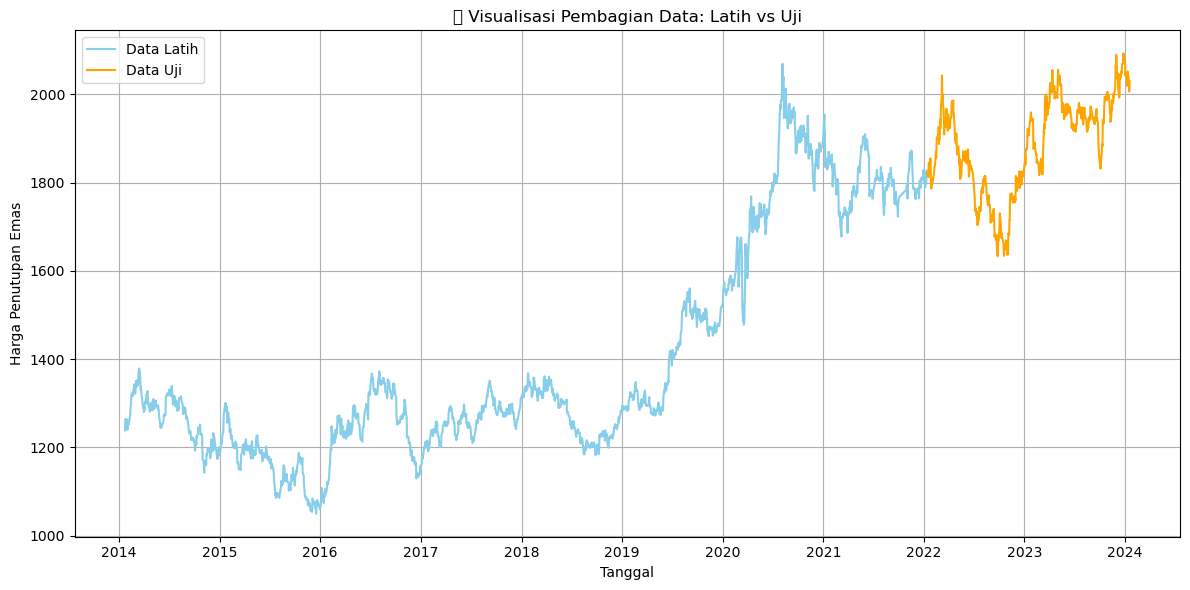

In [20]:
# Visualisasi pembagian data latih dan uji
plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Data Latih', color='skyblue')
plt.plot(y_test.index, y_test, label='Data Uji', color='orange')
plt.title('📊 Visualisasi Pembagian Data: Latih vs Uji')
plt.xlabel('Tanggal')
plt.ylabel('Harga Penutupan Emas')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Step 6 :- Model 

In [21]:
from sklearn.linear_model import LinearRegression 

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

LinearRegression()

## Step 7: Predictions 

📊 Model Evaluation (Linear Regression)

After training the model, we evaluate its performance using the following metrics:

- Mean Absolute Error (MAE)  
- Mean Squared Error (MSE)  
- R-squared (R² Score)  

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Prediction
y_pred = model_lr.predict(X_test)
print(y_pred)
print(y_pred.shape)

[1818.63270972 1822.61745864 1812.38216425 1834.96282433 1846.55516785
 1837.59459085 1841.23158981 1848.23362188 1828.57269188 1803.51182266
 1787.45913529 1794.5989903  1805.70842711 1805.37601305 1796.40035853
 1804.20307271 1820.42786254 1824.63291895 1834.22857228 1832.79323466
 1851.96376588 1865.8975944  1859.9605881  1867.44534645 1893.75196973
 1895.59954745 1904.90114903 1903.42770743 1933.77411079 1904.6890353
 1911.35344745 1936.54474315 1929.72835932 1935.86154254 1960.08650169
 1989.51867713 2045.26766127 2010.17225996 1996.77609394 1975.62799555
 1968.00613659 1924.39178265 1910.43454378 1947.32892884 1933.48029239
 1939.04439297 1926.816804   1943.08300661 1962.61614406 1959.03870076
 1935.79030546 1908.99927004 1936.13502839 1940.75467855 1930.19365442
 1932.27296035 1934.99392479 1927.75658392 1935.57909143 1945.39832504
 1963.57454617 1973.27780544 1979.65319578 1971.17176899 1994.13311191
 1959.62751535 1951.45469547 1945.67296252 1939.68673993 1906.77358245
 1907.2

In [23]:
print(y_test)
print(y_test.shape)

Date
2022-01-13    1821.4
2022-01-14    1816.5
2022-01-18    1812.4
2022-01-19    1845.5
2022-01-20    1844.9
               ...  
2024-01-12    2051.6
2024-01-16    2030.2
2024-01-17    2006.5
2024-01-18    2021.6
2024-01-19    2029.3
Name: Close, Length: 503, dtype: float64
(503,)


## Step 8 :- Evaluation 

In [24]:
# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [25]:
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Absolute Error (MAE): 5.41
Mean Squared Error (MSE): 46.23
R-squared (R²): 0.9959


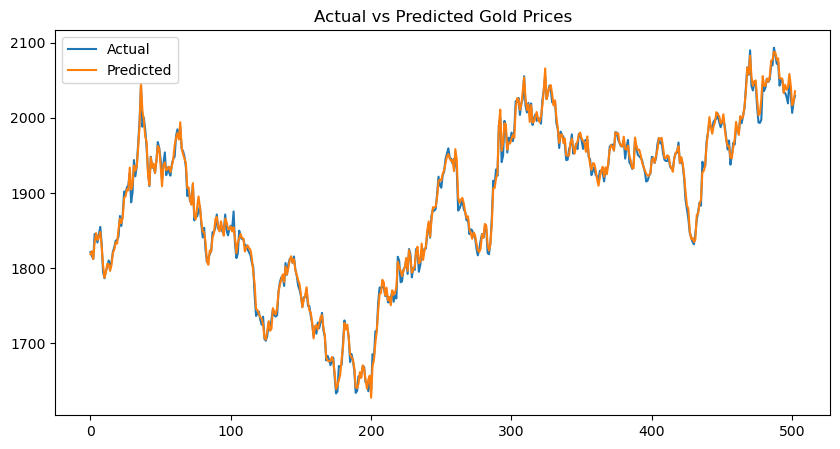

In [26]:
#Plot Actual vs Predicted Graph
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.title("Actual vs Predicted Gold Prices")
plt.legend()
plt.show()